/content
Classes found: ['cupuacu', 'tucuma', 'acai', 'pupunha', 'guarana', 'graviola']


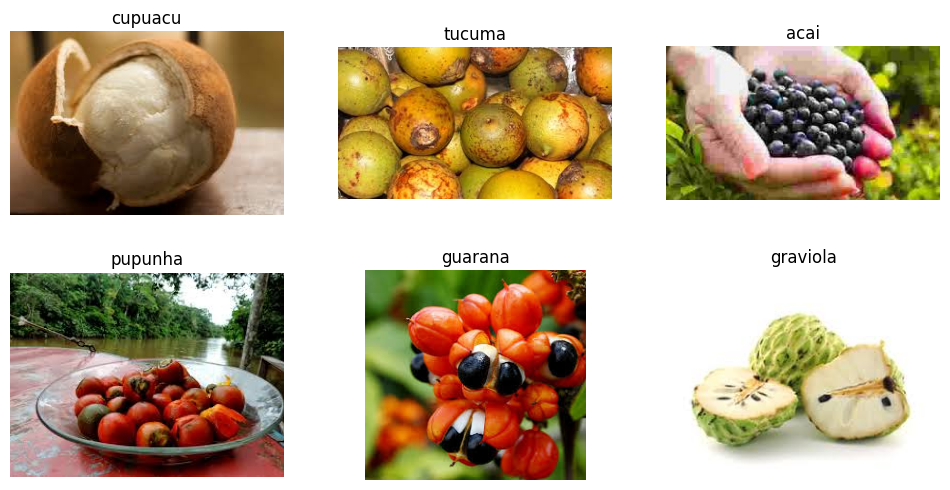

In [11]:
# Task 1: Data Understanding and Visualization:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
print(os.getcwd())

# Path to your training dataset
train_dir = "/content/drive/MyDrive/worksheet 5/FruitinAmazon/train"

# List class directories
class_dirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print("Classes found:", class_dirs)

# Select one random image from each class
sample_images = []
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    sample_images.append((cls, Image.open(img_path)))

# Display images in a 2-row grid
plt.figure(figsize=(12, 6))
for i, (cls, img) in enumerate(sample_images):
    plt.subplot(2, len(sample_images)//2 + len(sample_images)%2, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.show()

Each class folder contains visually different fruit categories.
Random sampling shows variation in lighting, shape, and background.
This indicates the dataset is suitable for CNN-based classification.

In [5]:
# 2. Check for Corrupted Image:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()  # Verify image is valid
        except (IOError, SyntaxError, UnidentifiedImageError):
            os.remove(img_path)
            corrupted_images.append(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No corrupted images found.")

No corrupted images found.


Found 90 files belonging to 6 classes.
Found 30 files belonging to 6 classes.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


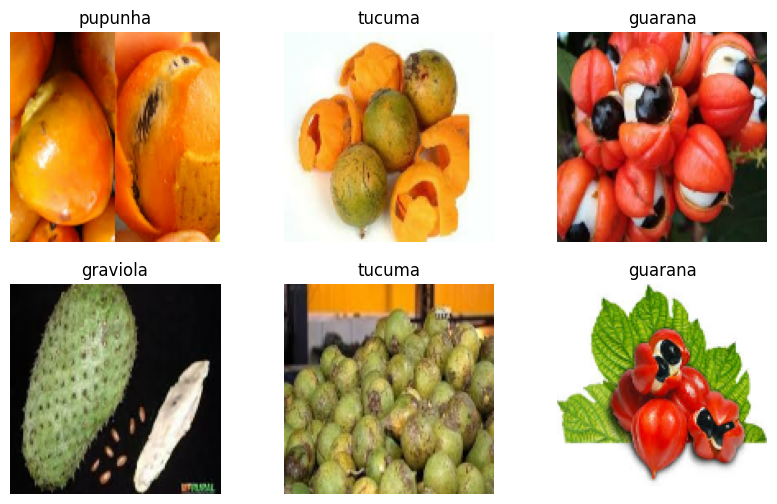

In [8]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

train_dir = "/content/drive/MyDrive/worksheet 5/FruitinAmazon/train"
val_dir = "/content/drive/MyDrive/worksheet 5/FruitinAmazon/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

rescale = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

plt.figure(figsize=(10, 6))

for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [10]:
# Task 3 - Implement a CNN with Follow the following Structure and Hyper - parameters:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2), strides=2),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Task 4: Compile the Model

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')  # 6 classes (your dataset)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# ask 4: Train the Model
import tensorflow as tf
from tensorflow.keras import layers

val_dir = "/content/drive/MyDrive/worksheet 5/FruitinAmazon/test"

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(128, 128),
    batch_size=32
)

class_names = val_ds.class_names

rescale = layers.Rescaling(1./255)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step


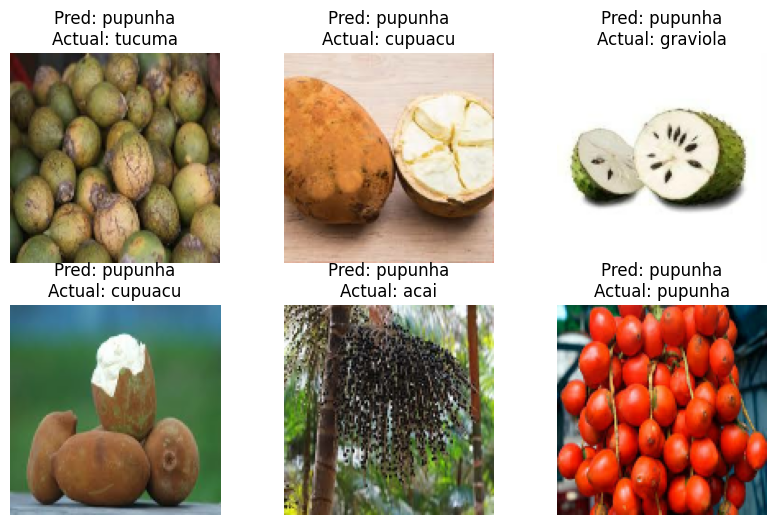

In [6]:
# Task 5: Evaluate the Model

import numpy as np
import matplotlib.pyplot as plt

for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    pred_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(10,6))
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(f"Pred: {class_names[pred_labels[i]]}\nActual: {class_names[labels[i]]}")
        plt.axis("off")
    plt.show()

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1667 - loss: 1.7931
Test Accuracy: 0.1666666716337204
Test Loss: 1.7931296825408936


In [16]:
# Task 6: Save and Load the Model

model.save("cnn_fruits_model.h5")

from tensorflow.keras.models import load_model

loaded_model = load_model("cnn_fruits_model.h5")
loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 861ms/step - accuracy: 0.1667 - loss: 1.7931


[1.793129563331604, 0.1666666716337204]

In [17]:

# Task 7: Predictions and Classification Report
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = loaded_model.predict(images)
    pred_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.17      1.00      0.29         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
